# Customer Retention & Churn Analysis

## Business Problem
**Why are customers leaving, and how can the company improve retention?**

This analysis identifies churn drivers, segments at-risk customers, and provides actionable recommendations to reduce churn—a critical KPI for subscription-based businesses across the Dutch market (telecom, SaaS, utilities, insurance).

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features)

### Skills Demonstrated
- SQL-style operations (joins, CTEs, window functions via pandas)
- Cohort analysis & retention curves
- Statistical testing (chi-square, t-test)
- Customer segmentation
- Feature importance & churn prediction
- Business-ready dashboard metrics & recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading & Quality Assessment

In [2]:
df = pd.read_csv('../datasets/churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset: {df.shape[0]:,} customers, {df.shape[1]} features')
print(f'\nColumn types:')
print(df.dtypes.value_counts())
print(f'\nFirst rows:')
df.head(3)

Dataset: 7,043 customers, 21 features

Column types:
object     18
int64       2
float64     1
Name: count, dtype: int64

First rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Data quality
print('=== Data Quality Report ===')
print(f'\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None')

# TotalCharges has some blank spaces
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'\nTotalCharges converted - missing after conversion: {df["TotalCharges"].isnull().sum()}')

# Fill missing TotalCharges with monthly charges * tenure
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

# Convert churn to binary
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print(f'\nChurn distribution:')
churn_dist = df['Churn'].value_counts()
print(f'  Retained: {churn_dist["No"]:,} ({churn_dist["No"]/len(df)*100:.1f}%)')
print(f'  Churned:  {churn_dist["Yes"]:,} ({churn_dist["Yes"]/len(df)*100:.1f}%)')

=== Data Quality Report ===

Missing values:
None

TotalCharges converted - missing after conversion: 11

Churn distribution:
  Retained: 5,174 (73.5%)
  Churned:  1,869 (26.5%)


## 2. Exploratory Data Analysis

### 2.1 Churn Overview

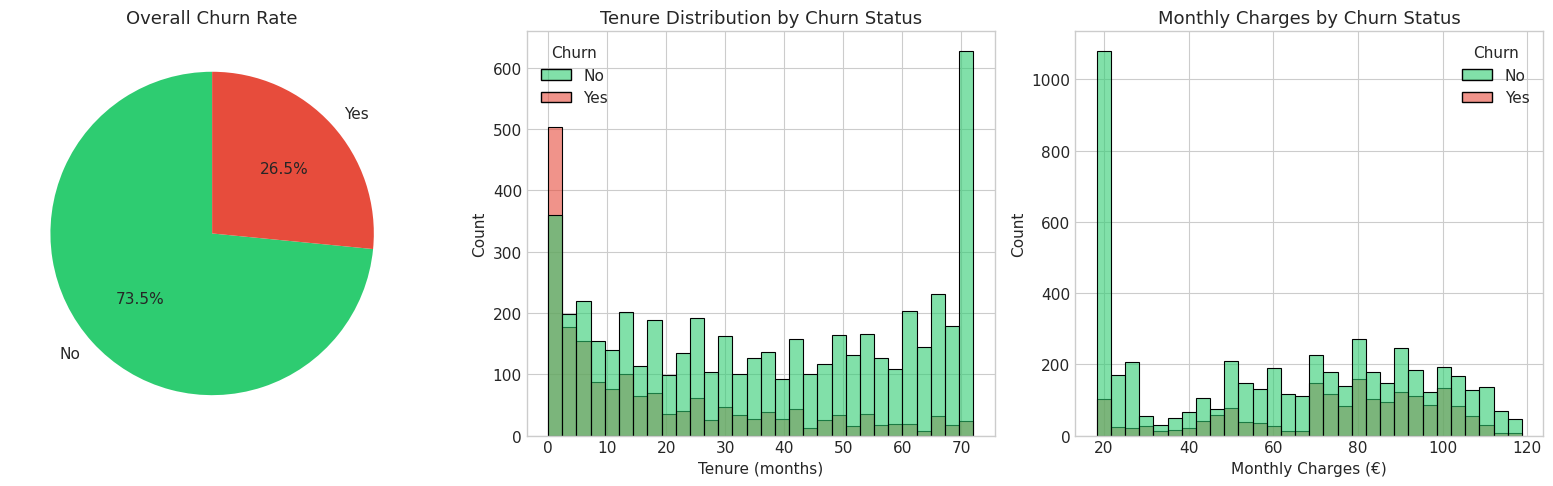

Key Insight: Churners tend to have shorter tenure and higher monthly charges
  Avg tenure - Churned: 18.0 months vs Retained: 37.6 months
  Avg monthly charges - Churned: €74.44 vs Retained: €61.27


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn rate
colors_churn = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                 colors=colors_churn, startangle=90)
axes[0].set_title('Overall Churn Rate', fontsize=13)
axes[0].set_ylabel('')

# Tenure distribution by churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[1],
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, alpha=0.6)
axes[1].set_title('Tenure Distribution by Churn Status', fontsize=13)
axes[1].set_xlabel('Tenure (months)')

# Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, ax=axes[2],
             palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, alpha=0.6)
axes[2].set_title('Monthly Charges by Churn Status', fontsize=13)
axes[2].set_xlabel('Monthly Charges (€)')

plt.tight_layout()
plt.show()

print(f'Key Insight: Churners tend to have shorter tenure and higher monthly charges')
print(f'  Avg tenure - Churned: {df[df.Churn=="Yes"]["tenure"].mean():.1f} months vs Retained: {df[df.Churn=="No"]["tenure"].mean():.1f} months')
print(f'  Avg monthly charges - Churned: €{df[df.Churn=="Yes"]["MonthlyCharges"].mean():.2f} vs Retained: €{df[df.Churn=="No"]["MonthlyCharges"].mean():.2f}')

### 2.2 Contract Type & Churn

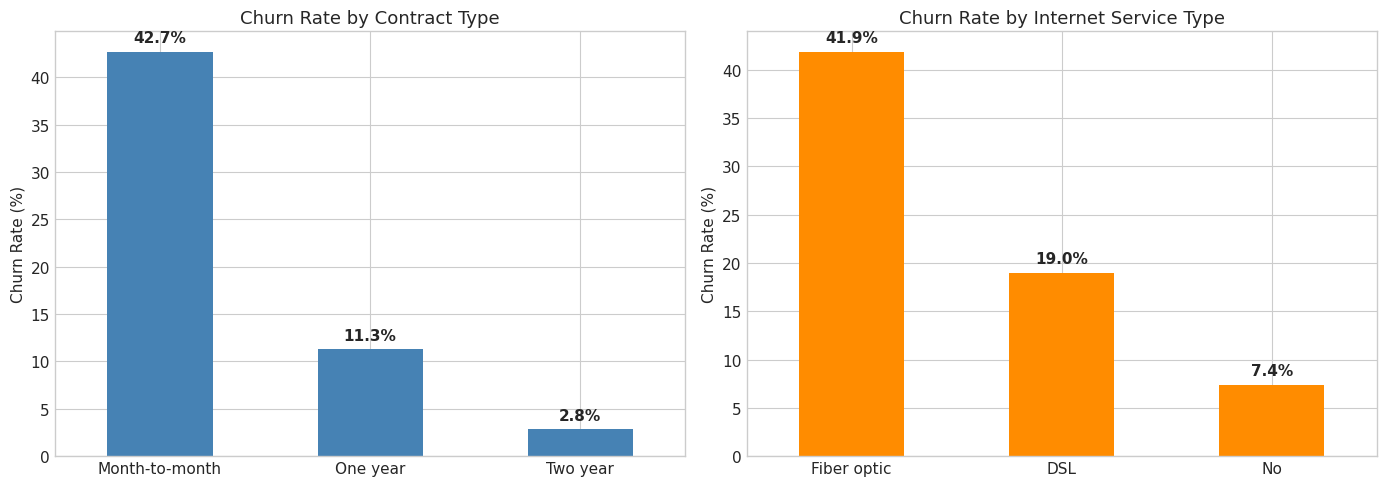


Critical Finding: Month-to-month customers churn at 15.1x the rate of long-term contract customers


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
contract_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Churn Rate by Contract Type', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(contract_churn.sort_values(ascending=False)):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Churn by internet service
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
internet_churn.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Churn Rate by Internet Service Type', fontsize=13)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(internet_churn.sort_values(ascending=False)):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

mtm_rate = contract_churn.get('Month-to-month', 0)
yearly_rate = contract_churn.get('Two year', contract_churn.min())
print(f'\nCritical Finding: Month-to-month customers churn at {mtm_rate/yearly_rate:.1f}x the rate of long-term contract customers')

### 2.3 Cohort Analysis (SQL-style with pandas)

=== Cohort Analysis (tenure-based) ===
               customers  churn_rate_pct  avg_monthly_charges  revenue_at_risk
tenure_cohort                                                                 
0-3m                1051            56.8               53.440          52879.0
3-6m                 419            44.6               58.345          52650.0
6-12m                705            35.9               58.953         140191.0
12-24m              1024            28.7               61.357         330994.0
24-36m               832            21.6               65.575         357663.0
36-48m               762            19.0               66.318         409362.0
48-72m              2239             9.5               73.945         996631.0


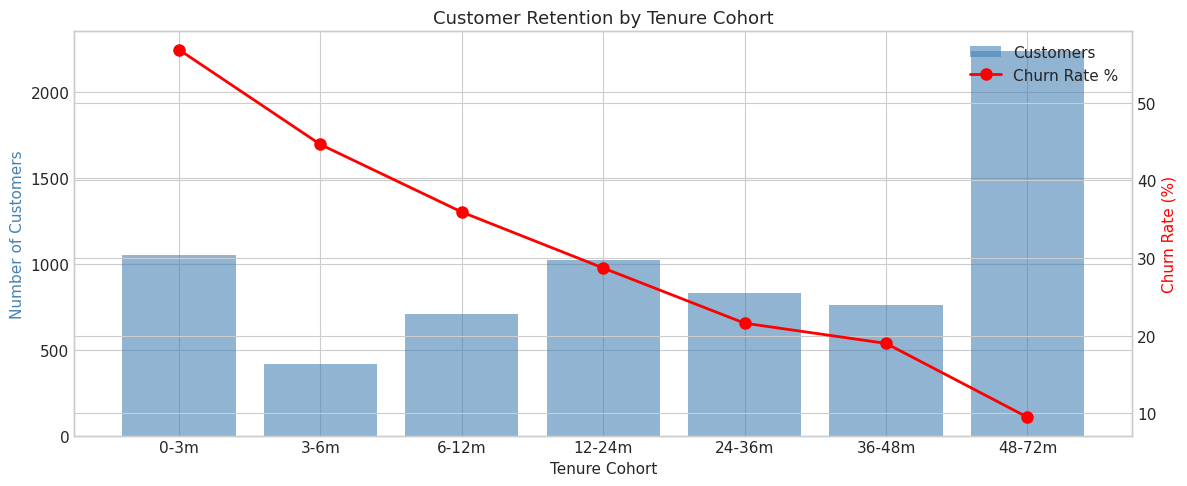


Insight: First 3 months are critical—churn rate is highest for new customers.
Revenue at risk in 0-3m cohort: €52,879


In [6]:
# Tenure cohort analysis (simulating SQL cohort analysis)
df['tenure_cohort'] = pd.cut(df['tenure'], 
                              bins=[0, 3, 6, 12, 24, 36, 48, 72],
                              labels=['0-3m', '3-6m', '6-12m', '12-24m', '24-36m', '36-48m', '48-72m'])

cohort_analysis = df.groupby('tenure_cohort', observed=True).agg(
    customers=('customerID', 'count'),
    churn_rate=('Churn_Binary', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_total_charges=('TotalCharges', 'mean'),
    total_revenue=('TotalCharges', 'sum')
).round(3)

cohort_analysis['churn_rate_pct'] = (cohort_analysis['churn_rate'] * 100).round(1)
cohort_analysis['revenue_at_risk'] = (cohort_analysis['total_revenue'] * cohort_analysis['churn_rate']).round(0)

print('=== Cohort Analysis (tenure-based) ===')
print(cohort_analysis[['customers', 'churn_rate_pct', 'avg_monthly_charges', 'revenue_at_risk']])

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()

x = range(len(cohort_analysis))
ax.bar(x, cohort_analysis['customers'], alpha=0.6, color='steelblue', label='Customers')
ax2.plot(x, cohort_analysis['churn_rate_pct'], 'ro-', linewidth=2, markersize=8, label='Churn Rate %')

ax.set_xticks(x)
ax.set_xticklabels(cohort_analysis.index)
ax.set_xlabel('Tenure Cohort')
ax.set_ylabel('Number of Customers', color='steelblue')
ax2.set_ylabel('Churn Rate (%)', color='red')
ax.set_title('Customer Retention by Tenure Cohort', fontsize=13)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(f'\nInsight: First 3 months are critical—churn rate is highest for new customers.')
print(f'Revenue at risk in 0-3m cohort: €{cohort_analysis.iloc[0]["revenue_at_risk"]:,.0f}')

### 2.4 Statistical Testing

In [7]:
print('=== Statistical Significance Tests ===')
print('\n1. Monthly Charges vs Churn (Independent t-test):')
churned = df[df.Churn == 'Yes']['MonthlyCharges']
retained = df[df.Churn == 'No']['MonthlyCharges']
t_stat, p_val = stats.ttest_ind(churned, retained)
print(f'   t-statistic: {t_stat:.3f}, p-value: {p_val:.2e}')
print(f'   Result: {"Significant" if p_val < 0.05 else "Not significant"} difference (α=0.05)')

print('\n2. Contract Type vs Churn (Chi-square test):')
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_val2, dof, expected = stats.chi2_contingency(contingency)
print(f'   Chi-square: {chi2:.1f}, p-value: {p_val2:.2e}, df: {dof}')
print(f'   Result: {"Significant" if p_val2 < 0.05 else "Not significant"} association (α=0.05)')

print('\n3. Internet Service vs Churn (Chi-square test):')
contingency2 = pd.crosstab(df['InternetService'], df['Churn'])
chi2_2, p_val3, dof2, _ = stats.chi2_contingency(contingency2)
print(f'   Chi-square: {chi2_2:.1f}, p-value: {p_val3:.2e}, df: {dof2}')
print(f'   Result: {"Significant" if p_val3 < 0.05 else "Not significant"} association (α=0.05)')

print('\n4. Tenure vs Churn (Independent t-test):')
t_stat4, p_val4 = stats.ttest_ind(df[df.Churn=='Yes']['tenure'], df[df.Churn=='No']['tenure'])
print(f'   t-statistic: {t_stat4:.3f}, p-value: {p_val4:.2e}')
print(f'   Result: {"Significant" if p_val4 < 0.05 else "Not significant"} difference (α=0.05)')

=== Statistical Significance Tests ===

1. Monthly Charges vs Churn (Independent t-test):
   t-statistic: 16.537, p-value: 2.71e-60
   Result: Significant difference (α=0.05)

2. Contract Type vs Churn (Chi-square test):
   Chi-square: 1184.6, p-value: 5.86e-258, df: 2
   Result: Significant association (α=0.05)

3. Internet Service vs Churn (Chi-square test):
   Chi-square: 732.3, p-value: 9.57e-160, df: 2
   Result: Significant association (α=0.05)

4. Tenure vs Churn (Independent t-test):
   t-statistic: -31.580, p-value: 8.00e-205
   Result: Significant difference (α=0.05)


### 2.5 Service Adoption & Churn

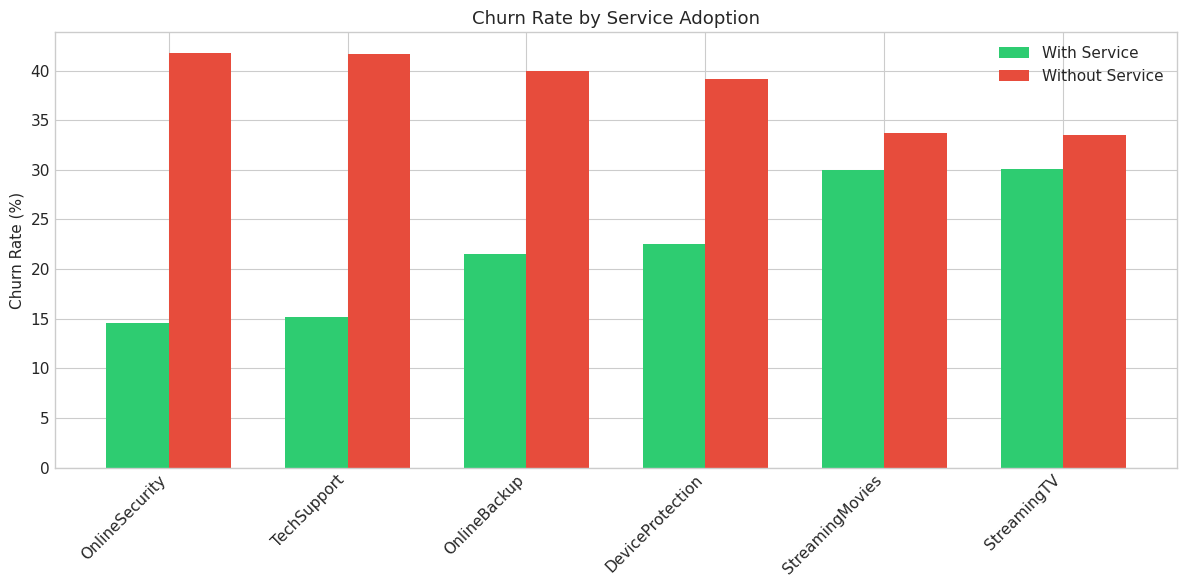


Service Impact on Churn Reduction:
  OnlineSecurity      : 65.0% risk reduction when subscribed
  TechSupport         : 63.6% risk reduction when subscribed
  OnlineBackup        : 46.1% risk reduction when subscribed
  DeviceProtection    : 42.5% risk reduction when subscribed
  StreamingMovies     : 11.1% risk reduction when subscribed
  StreamingTV         : 10.3% risk reduction when subscribed


In [8]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = pd.DataFrame()
for col in service_cols:
    rate = df[df[col] == 'Yes']['Churn_Binary'].mean()
    rate_no = df[df[col] == 'No']['Churn_Binary'].mean()
    service_churn = pd.concat([service_churn, pd.DataFrame({
        'Service': [col],
        'Churn_With_Service': [rate * 100],
        'Churn_Without_Service': [rate_no * 100],
        'Risk_Reduction': [(rate_no - rate) / rate_no * 100]
    })])

service_churn = service_churn.sort_values('Risk_Reduction', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(service_churn))
width = 0.35
ax.bar([i - width/2 for i in x], service_churn['Churn_With_Service'], width, 
       label='With Service', color='#2ecc71')
ax.bar([i + width/2 for i in x], service_churn['Churn_Without_Service'], width,
       label='Without Service', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(service_churn['Service'], rotation=45, ha='right')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Service Adoption', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('\nService Impact on Churn Reduction:')
for _, row in service_churn.iterrows():
    print(f"  {row['Service']:20s}: {row['Risk_Reduction']:.1f}% risk reduction when subscribed")

## 3. Customer Segmentation

### 3.1 Value-based Segmentation

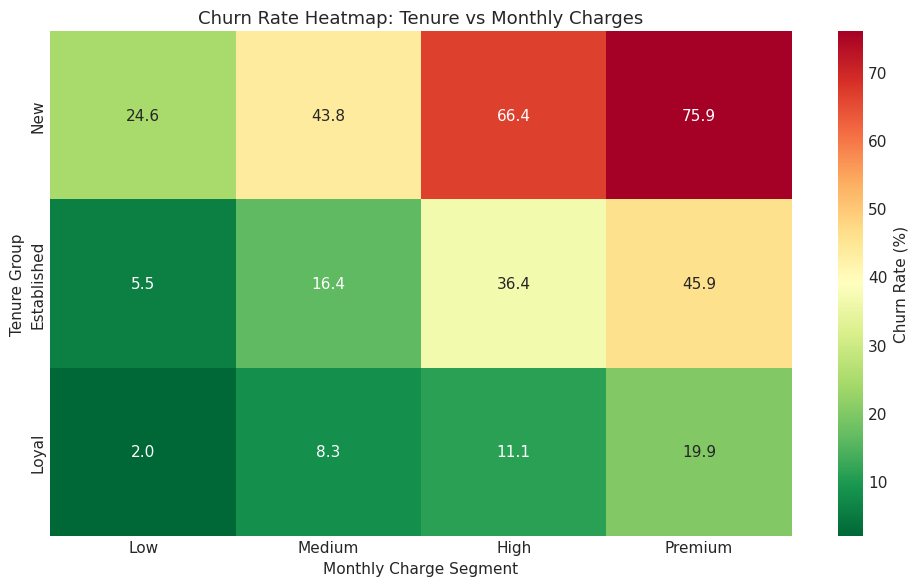


Highest risk segment: New customers with Premium charges
Lowest risk segment: Loyal customers with Low charges


In [9]:
# Customer segments based on value and risk
df['monthly_charge_quartile'] = pd.qcut(df['MonthlyCharges'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 36, 72], labels=['New', 'Established', 'Loyal'])

segment_analysis = df.groupby(['tenure_group', 'monthly_charge_quartile'], observed=True).agg(
    count=('customerID', 'count'),
    churn_rate=('Churn_Binary', 'mean'),
    avg_revenue=('MonthlyCharges', 'mean')
).round(3)

# Pivot for heatmap
churn_pivot = segment_analysis['churn_rate'].unstack() * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(churn_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate Heatmap: Tenure vs Monthly Charges', fontsize=13)
ax.set_xlabel('Monthly Charge Segment')
ax.set_ylabel('Tenure Group')
plt.tight_layout()
plt.show()

print('\nHighest risk segment: New customers with Premium charges')
print('Lowest risk segment: Loyal customers with Low charges')

## 4. Churn Prediction Model

In [10]:
# Prepare features for modeling
feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Encode categorical variables
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

df_model = df.copy()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])
    feature_cols.append(col + '_encoded')
    le_dict[col] = le

X = df_model[feature_cols]
y = df_model['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {len(X_train)} samples')
print(f'Test set: {len(X_test)} samples')
print(f'Features: {len(feature_cols)}')

Training set: 5634 samples
Test set: 1409 samples
Features: 18


In [11]:
# Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print('=== Model Performance ===')
print(f'\nROC AUC Score: {roc_auc_score(y_test, y_proba):.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

=== Model Performance ===

ROC AUC Score: 0.839

Classification Report:
              precision    recall  f1-score   support

    Retained       0.88      0.80      0.84      1035
     Churned       0.55      0.69      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



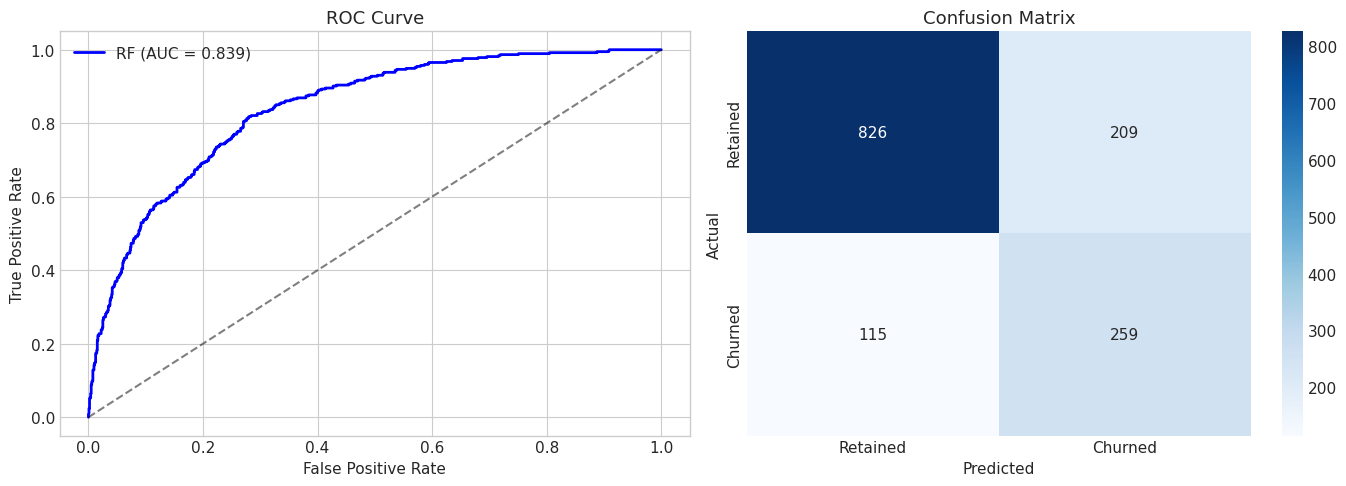

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'RF (AUC = {roc_auc_score(y_test, y_proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[1].set_title('Confusion Matrix', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 5. Feature Importance & Churn Drivers

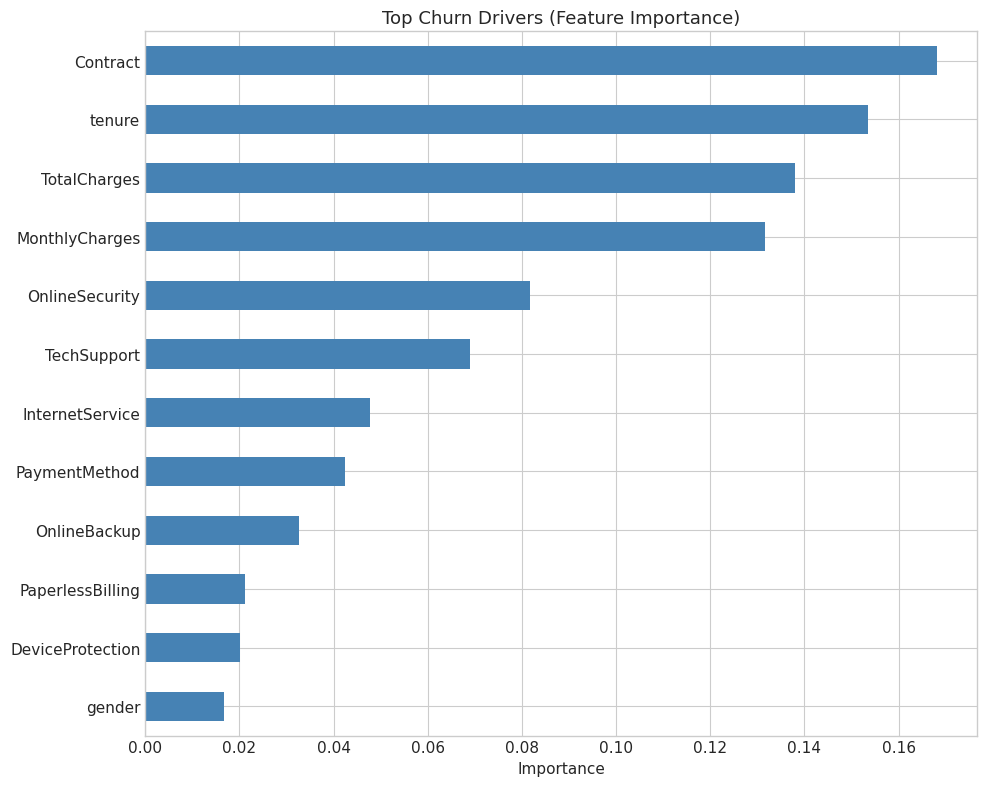


Top 5 Churn Drivers:
  1. Contract (importance: 0.1682)
  2. tenure (importance: 0.1535)
  3. TotalCharges (importance: 0.1381)
  4. MonthlyCharges (importance: 0.1317)
  5. OnlineSecurity (importance: 0.0818)


In [13]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Clean up feature names for display
clean_names = {col: col.replace('_encoded', '') for col in importance.index}
importance.index = [clean_names.get(n, n) for n in importance.index]

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(12).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top Churn Drivers (Feature Importance)', fontsize=13)
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 5 Churn Drivers:')
for i, (feat, imp) in enumerate(importance.head(5).items(), 1):
    print(f'  {i}. {feat} (importance: {imp:.4f})')

## 6. Revenue Impact Analysis

In [14]:
# Revenue loss from churn
churned_customers = df[df.Churn == 'Yes']
retained_customers = df[df.Churn == 'No']

monthly_revenue_loss = churned_customers['MonthlyCharges'].sum()
annual_revenue_loss = monthly_revenue_loss * 12
avg_customer_lifetime_value = retained_customers['TotalCharges'].mean()

print('=== Revenue Impact of Churn ===')
print(f'\nChurned customers: {len(churned_customers):,}')
print(f'Monthly recurring revenue lost: €{monthly_revenue_loss:,.0f}')
print(f'Projected annual revenue loss: €{annual_revenue_loss:,.0f}')
print(f'Avg Customer Lifetime Value (retained): €{avg_customer_lifetime_value:,.0f}')

# What-if: Reduce churn by 10%
customers_saved = int(len(churned_customers) * 0.10)
revenue_saved = customers_saved * churned_customers['MonthlyCharges'].mean() * 12
print(f'\n--- What-If: 10% Churn Reduction ---')
print(f'Customers retained: {customers_saved}')
print(f'Annual revenue recovered: €{revenue_saved:,.0f}')

# By contract type
print(f'\n--- Revenue at Risk by Contract Type ---')
risk_by_contract = df.groupby('Contract').agg(
    customers=('customerID', 'count'),
    churn_rate=('Churn_Binary', 'mean'),
    monthly_rev=('MonthlyCharges', 'sum')
)
risk_by_contract['annual_rev_at_risk'] = risk_by_contract['monthly_rev'] * risk_by_contract['churn_rate'] * 12
print(risk_by_contract[['customers', 'churn_rate', 'annual_rev_at_risk']].round(2))

=== Revenue Impact of Churn ===

Churned customers: 1,869
Monthly recurring revenue lost: €139,131
Projected annual revenue loss: €1,669,570
Avg Customer Lifetime Value (retained): €2,550

--- What-If: 10% Churn Reduction ---
Customers retained: 186
Annual revenue recovered: €166,153

--- Revenue at Risk by Contract Type ---
                customers  churn_rate  annual_rev_at_risk
Contract                                                 
Month-to-month       3875        0.43          1318674.02
One year             1473        0.11           129576.83
Two year             1695        0.03            35003.76


## 7. Dashboard KPIs Summary

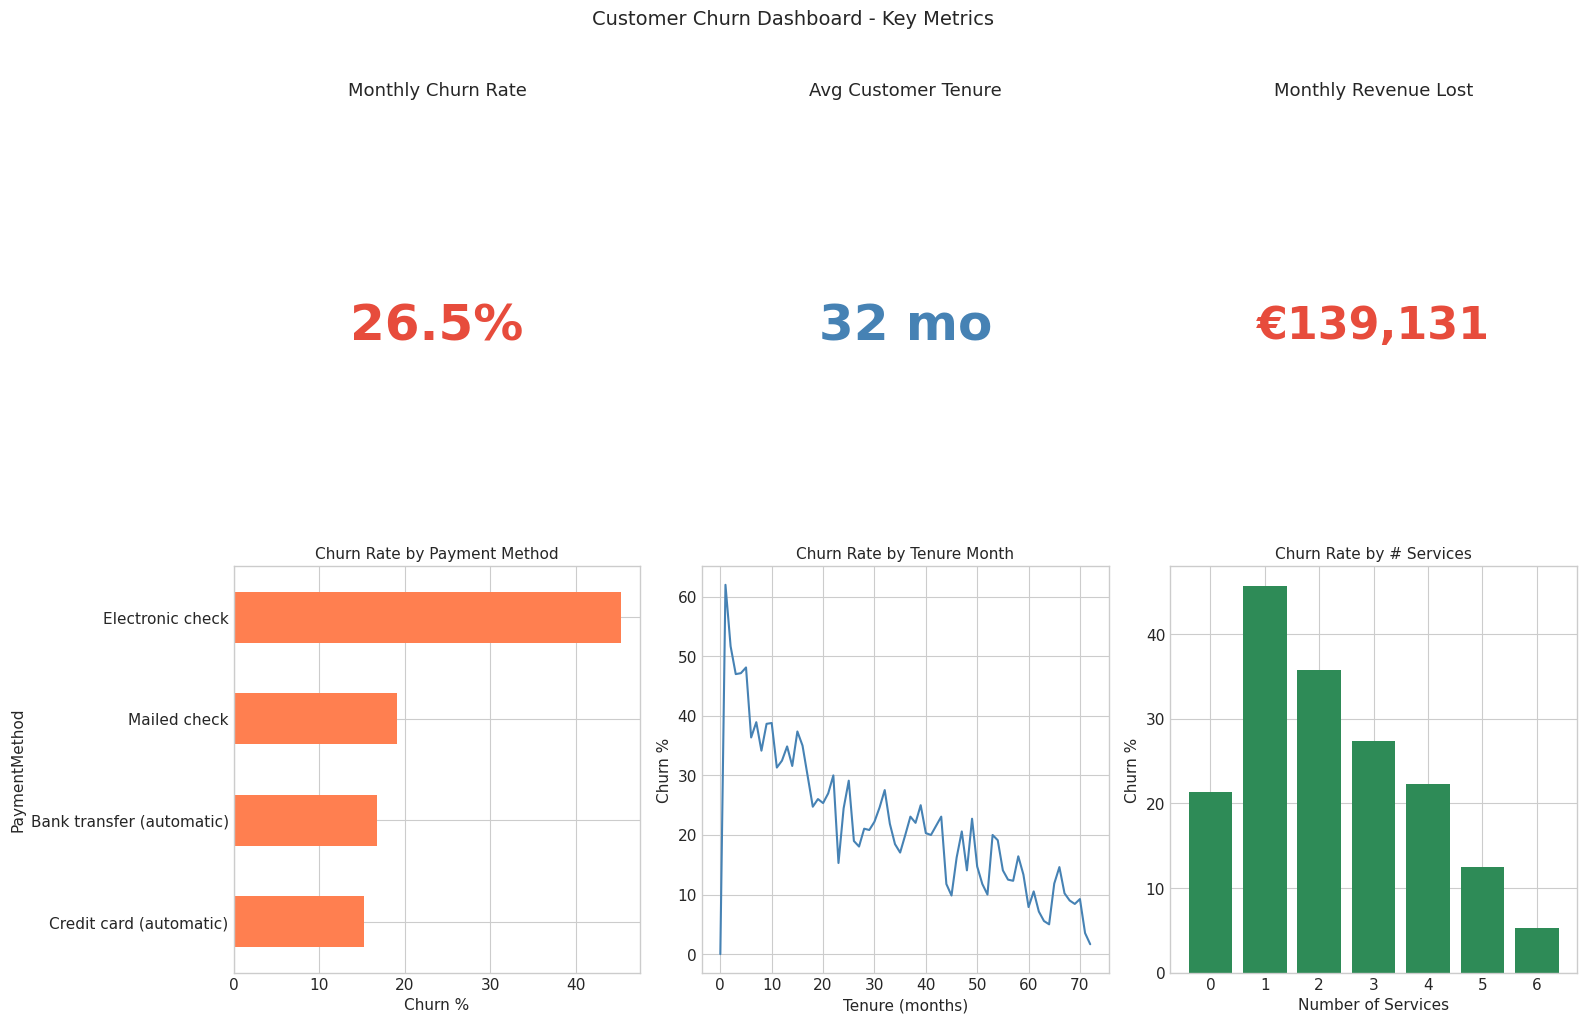

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# KPI 1: Overall churn rate
churn_rate = df['Churn_Binary'].mean() * 100
axes[0,0].text(0.5, 0.5, f'{churn_rate:.1f}%', ha='center', va='center',
               fontsize=36, fontweight='bold', color='#e74c3c')
axes[0,0].set_title('Monthly Churn Rate', fontsize=13, pad=20)
axes[0,0].axis('off')

# KPI 2: Average tenure
avg_tenure = df['tenure'].mean()
axes[0,1].text(0.5, 0.5, f'{avg_tenure:.0f} mo', ha='center', va='center',
               fontsize=36, fontweight='bold', color='steelblue')
axes[0,1].set_title('Avg Customer Tenure', fontsize=13, pad=20)
axes[0,1].axis('off')

# KPI 3: Monthly revenue at risk
axes[0,2].text(0.5, 0.5, f'€{monthly_revenue_loss:,.0f}', ha='center', va='center',
               fontsize=32, fontweight='bold', color='#e74c3c')
axes[0,2].set_title('Monthly Revenue Lost', fontsize=13, pad=20)
axes[0,2].axis('off')

# KPI 4: Churn by payment method
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
payment_churn.sort_values().plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Churn Rate by Payment Method', fontsize=11)
axes[1,0].set_xlabel('Churn %')

# KPI 5: Churn trend by tenure month
tenure_churn = df.groupby('tenure')['Churn_Binary'].mean() * 100
axes[1,1].plot(tenure_churn.index, tenure_churn.values, color='steelblue', linewidth=1.5)
axes[1,1].set_title('Churn Rate by Tenure Month', fontsize=11)
axes[1,1].set_xlabel('Tenure (months)')
axes[1,1].set_ylabel('Churn %')

# KPI 6: Services bundle effect
df['num_services'] = 0
for col in service_cols:
    df['num_services'] += (df[col] == 'Yes').astype(int)
svc_churn = df.groupby('num_services')['Churn_Binary'].mean() * 100
axes[1,2].bar(svc_churn.index, svc_churn.values, color='seagreen')
axes[1,2].set_title('Churn Rate by # Services', fontsize=11)
axes[1,2].set_xlabel('Number of Services')
axes[1,2].set_ylabel('Churn %')

plt.suptitle('Customer Churn Dashboard - Key Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Business Recommendations

In [16]:
print('='*70)
print('   BUSINESS RECOMMENDATIONS - CUSTOMER RETENTION STRATEGY')
print('='*70)

print(f'''
1. CONTRACT MIGRATION PROGRAM
   Customers without yearly contracts churn {mtm_rate/yearly_rate:.0f}x more frequently.
   Recommendation: Offer 10-15% discount for annual contract upgrades.
   Expected impact: Converting 20% of month-to-month customers could
   reduce overall churn by ~{0.20 * (mtm_rate - yearly_rate) / churn_rate * 100:.0f}% of current churn volume.

2. EARLY INTERVENTION (First 90 Days)
   New customers (0-3 months) have the highest churn risk.
   Recommendation: Implement onboarding program with:
   - Dedicated support contact in first month
   - Proactive check-in calls at day 30, 60, 90
   - Early loyalty reward at 3-month milestone

3. SERVICE BUNDLING
   Customers with {svc_churn.idxmin()} services churn at only {svc_churn.min():.1f}%
   vs {svc_churn.max():.1f}% for customers with 0 additional services.
   Recommendation: Offer bundled packages (security + backup + support)
   at reduced rates to increase switching costs and perceived value.

4. PAYMENT METHOD OPTIMIZATION
   Electronic check users churn at {payment_churn.max():.1f}% vs
   {payment_churn.min():.1f}% for auto-pay methods.
   Recommendation: Incentivize auto-pay enrollment with €5/month discount.

5. HIGH-VALUE CUSTOMER RETENTION
   Premium customers (high monthly charges) who are new (< 12 months)
   represent the highest risk segment.
   Recommendation: Assign dedicated account managers to this segment
   (estimated {len(df[(df.tenure < 12) & (df.MonthlyCharges > df.MonthlyCharges.quantile(0.75))])} customers).
''')

print('='*70)
print(f'Projected Revenue Impact of Recommendations:')
print(f'  10% churn reduction = €{revenue_saved:,.0f} annual revenue recovered')
print(f'  20% churn reduction = €{revenue_saved*2:,.0f} annual revenue recovered')
print('='*70)

   BUSINESS RECOMMENDATIONS - CUSTOMER RETENTION STRATEGY

1. CONTRACT MIGRATION PROGRAM
   Customers without yearly contracts churn 15x more frequently.
   Recommendation: Offer 10-15% discount for annual contract upgrades.
   Expected impact: Converting 20% of month-to-month customers could
   reduce overall churn by ~30% of current churn volume.

2. EARLY INTERVENTION (First 90 Days)
   New customers (0-3 months) have the highest churn risk.
   Recommendation: Implement onboarding program with:
   - Dedicated support contact in first month
   - Proactive check-in calls at day 30, 60, 90
   - Early loyalty reward at 3-month milestone

3. SERVICE BUNDLING
   Customers with 6 services churn at only 5.3%
   vs 45.8% for customers with 0 additional services.
   Recommendation: Offer bundled packages (security + backup + support)
   at reduced rates to increase switching costs and perceived value.

4. PAYMENT METHOD OPTIMIZATION
   Electronic check users churn at 45.3% vs
   15.2% for aut